In [120]:
import pandas as pd

df = pd.read_csv("../data/ranks.csv", parse_dates=["release_date"])


In [121]:
N = 3  # number of longs and shorts per day

# Top N per day → "long"
longs = (
    df.groupby("release_date", group_keys=False)
      .apply(lambda g: g.nlargest(N, "pred_30d"))
      .assign(side="long")
)

# Bottom N per day → "short"
shorts = (
    df.groupby("release_date", group_keys=False)
      .apply(lambda g: g.nsmallest(N, "pred_30d"))
      .assign(side="short")
)

signals = pd.concat([longs, shorts], ignore_index=True)

print(signals)


            id  pred_10d  pred_30d release_date   side
0          APT  0.988166  1.000000   2025-06-05   long
1     CHILLGUY  0.974359  0.984221   2025-06-05   long
2          ETH  0.960552  0.982249   2025-06-05   long
3          APT  1.000000  1.000000   2025-06-06   long
4       PROMPT  0.479290  0.984221   2025-06-06   long
...        ...       ...       ...          ...    ...
1063      TNSR  0.092170  0.107108   2025-11-28  short
1064     MAVIA  0.206094  0.114156   2025-11-28  short
1065     MAVIA  0.161945  0.078625   2025-11-29  short
1066        2Z  0.167425  0.091396   2025-11-29  short
1067       WCT  0.077233  0.092066   2025-11-29  short

[1068 rows x 5 columns]


/var/folders/fp/yk9rfr6n38b7lsdpdkhm511h0000gn/T/ipykernel_1776/2906329858.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(N, "pred_30d"))
/var/folders/fp/yk9rfr6n38b7lsdpdkhm511h0000gn/T/ipykernel_1776/2906329858.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nsmallest(N, "pred_30d"))


In [122]:
mean_by_side = signals.groupby("side")["pred_30d"].mean()
print(mean_by_side)


side
long     0.868959
short    0.125685
Name: pred_30d, dtype: float64


In [123]:
mean_by_day_side = (
    signals.groupby(["release_date", "side"])["pred_30d"]
           .mean()
           .unstack("side")   # columns: long, short
)
print(mean_by_day_side)


side              long     short
release_date                    
2025-06-05    0.988823  0.015779
2025-06-06    0.988166  0.011834
2025-06-07    0.968321  0.044832
2025-06-08    0.985536  0.012492
2025-06-09    0.982249  0.011834
...                ...       ...
2025-11-25    0.902279  0.109980
2025-11-26    0.880482  0.124613
2025-11-27    0.884354  0.118045
2025-11-28    0.925514  0.107152
2025-11-29    0.918802  0.087362

[178 rows x 2 columns]


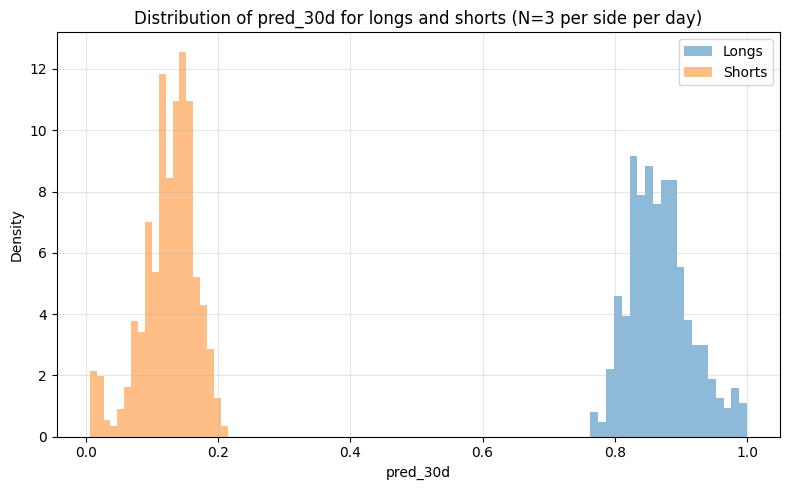

In [124]:
import matplotlib.pyplot as plt

# Extract series
long_preds  = signals.loc[signals["side"] == "long",  "pred_30d"]
short_preds = signals.loc[signals["side"] == "short", "pred_30d"]

plt.figure(figsize=(8, 5))
plt.hist(long_preds, bins=20, alpha=0.5, label="Longs", density=True)
plt.hist(short_preds, bins=20, alpha=0.5, label="Shorts", density=True)
plt.xlabel("pred_30d")
plt.ylabel("Density")
plt.title(f"Distribution of pred_30d for longs and shorts (N={N} per side per day)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


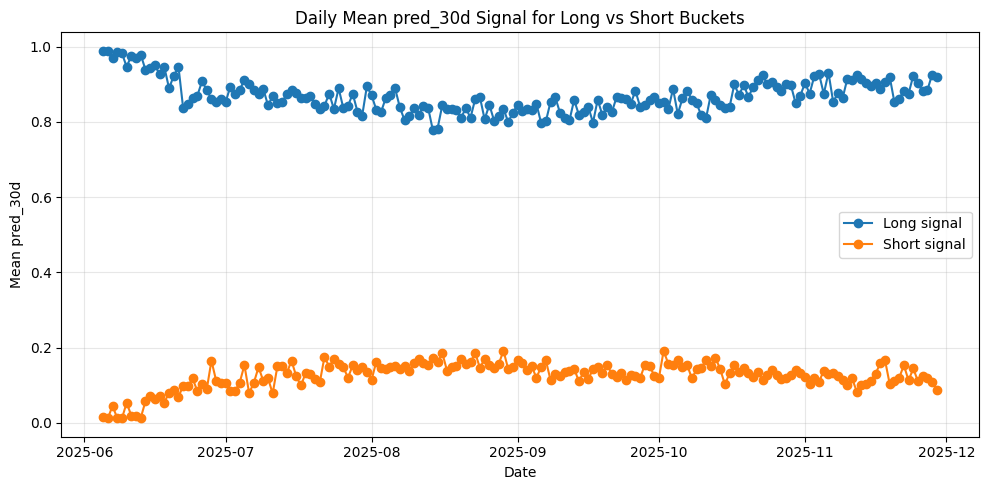

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(mean_by_day_side.index, mean_by_day_side["long"],  marker='o', label="Long signal")
plt.plot(mean_by_day_side.index, mean_by_day_side["short"], marker='o', label="Short signal")

plt.title("Daily Mean pred_30d Signal for Long vs Short Buckets")
plt.xlabel("Date")
plt.ylabel("Mean pred_30d")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [126]:
import pandas as pd

prices = pd.read_csv("../data/perps_prices_19.csv", parse_dates=["time"])

def compute_forward_return(df, horizon=30):
    df = df.sort_values("time")
    df["future_close"] = df["close"].shift(-horizon)
    df["fwd_ret"] = (df["future_close"] - df["close"]) / df["close"]
    return df

prices = prices.groupby("perp", group_keys=False).apply(compute_forward_return)

# round timestamps to date for matching (if time-of-day is different)
prices["date"] = prices["time"].dt.date
signals["date"] = signals["release_date"].dt.date

merged = signals.merge(
    prices,
    left_on=["id", "date"],
    right_on=["perp", "date"],
    how="left"
)

merged.head(20)


/var/folders/fp/yk9rfr6n38b7lsdpdkhm511h0000gn/T/ipykernel_1776/1099662972.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prices = prices.groupby("perp", group_keys=False).apply(compute_forward_return)


,id,pred_10d,pred_30d,release_date,side,date,perp,time,close,future_close,fwd_ret
0,APT,0.988166,1.000000,2025-06-05,long,2025-06-05,APT,2025-06-05 19:00:00+00:00,4.620400,4.403400,-0.046966
1,CHILLGUY,0.974359,0.984221,2025-06-05,long,2025-06-05,CHILLGUY,2025-06-05 19:00:00+00:00,0.057217,0.052364,-0.084817
2,ETH,0.960552,0.982249,2025-06-05,long,2025-06-05,ETH,2025-06-05 19:00:00+00:00,2529.900000,2505.500000,-0.009645
3,APT,1.000000,1.000000,2025-06-06,long,2025-06-06,APT,2025-06-06 19:00:00+00:00,4.600700,4.452800,-0.032147
4,PROMPT,0.479290,0.984221,2025-06-06,long,2025-06-06,PROMPT,2025-06-06 19:00:00+00:00,0.175320,0.129500,-0.261351
5,GMX,0.449704,0.980276,2025-06-06,long,2025-06-06,GMX,2025-06-06 19:00:00+00:00,15.065000,13.998000,-0.070826
6,BTC,0.965151,0.981916,2025-06-07,long,2025-06-07,BTC,2025-06-07 19:00:00+00:00,105672.000000,108062.000000,0.022617
7,ADA,0.949683,0.962504,2025-06-07,long,2025-06-07,ADA,2025-06-07 19:00:00+00:00,0.663910,0.579810,-0.126674
8,BNB,0.890522,0.960542,2025-06-07,long,2025-06-07,BNB,2025-06-07 19:00:00+00:00,651.540000,661.110000,0.014688
9,VVV,0.934911,0.996055,2025-06-08,long,2025-06-08,VVV,2025-06-08 19:00:00+00:00,3.021800,2.760900,-0.086339


In [127]:

long_df = merged[merged["side"] == "long"].dropna(subset=["fwd_ret"])
corr_long = long_df["pred_30d"].corr(long_df["fwd_ret"])

short_df = merged[merged["side"] == "short"].dropna(subset=["fwd_ret"])
corr_short = short_df["pred_30d"].corr(-short_df["fwd_ret"])

print("Long signal correlation:", corr_long)
print("Short signal correlation:", corr_short)



Long signal correlation: 0.0520761771606754
Short signal correlation: 0.06647819942332991


In [128]:
long_df  = merged[merged["side"] == "long"].dropna(subset=["fwd_ret"])
short_df = merged[merged["side"] == "short"].dropna(subset=["fwd_ret"])


Profitable long trades: 41.57%
Losing long trades: 58.43%


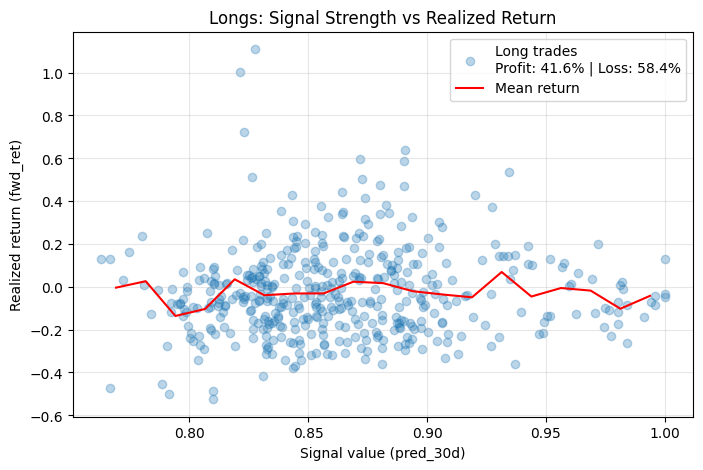

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

# LONGS
x = long_df["pred_30d"]
y = long_df["fwd_ret"]

# Profitability stats
total_trades = len(y)
profitable = (y > 0).sum()
losing = (y < 0).sum()

pct_profitable = profitable / total_trades * 100
pct_losing = losing / total_trades * 100

print(f"Profitable long trades: {pct_profitable:.2f}%")
print(f"Losing long trades: {pct_losing:.2f}%")

# --- Plot ---
plt.figure(figsize=(8,5))

plt.scatter(x, y, alpha=0.3, label=f"Long trades\nProfit: {pct_profitable:.1f}% | Loss: {pct_losing:.1f}%")

# smoothed mean line
bins = np.linspace(x.min(), x.max(), 20)
bin_means, _, _ = binned_statistic(x, y, statistic="mean", bins=bins)
plt.plot((bins[:-1] + bins[1:]) / 2, bin_means, color="red", label="Mean return")

plt.xlabel("Signal value (pred_30d)")
plt.ylabel("Realized return (fwd_ret)")
plt.title("Longs: Signal Strength vs Realized Return")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


Profitable short trades: 72.52%
Losing short trades: 27.48%


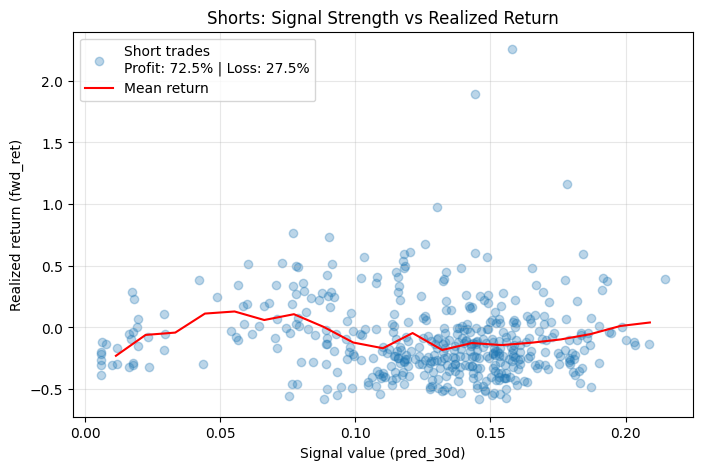

In [130]:
# SHORTS
x = short_df["pred_30d"]
y = short_df["fwd_ret"]

# Profitability stats for shorts
total_trades = len(y)
profitable = (y < 0).sum()      # price went down → good for short
losing = (y > 0).sum()          # price went up → losing short

pct_profitable = profitable / total_trades * 100
pct_losing = losing / total_trades * 100

print(f"Profitable short trades: {pct_profitable:.2f}%")
print(f"Losing short trades: {pct_losing:.2f}%")


# --- Plot ---
plt.figure(figsize=(8,5))

plt.scatter(x, y, alpha=0.3, 
            label=f"Short trades\nProfit: {pct_profitable:.1f}% | Loss: {pct_losing:.1f}%")

# smoothed mean line
bins = np.linspace(x.min(), x.max(), 20)
bin_means, _, _ = binned_statistic(x, y, statistic="mean", bins=bins)
plt.plot((bins[:-1] + bins[1:]) / 2, bin_means, color="red", label="Mean return")

plt.xlabel("Signal value (pred_30d)")
plt.ylabel("Realized return (fwd_ret)")
plt.title("Shorts: Signal Strength vs Realized Return")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

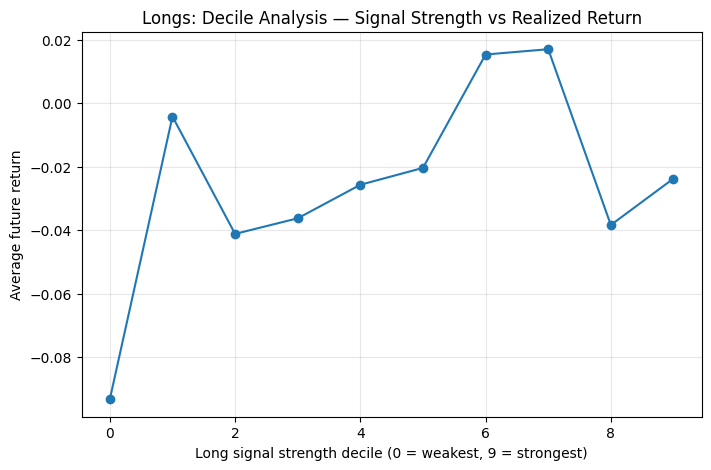

Long decile mean returns:
signal_bin
0   -0.093268
1   -0.004168
2   -0.041157
3   -0.036242
4   -0.025674
5   -0.020357
6    0.015383
7    0.017050
8   -0.038347
9   -0.023726
Name: fwd_ret, dtype: float64


In [131]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# LONGS
df_long = long_df.copy()

# 10 quantile bins
df_long["signal_bin"] = pd.qcut(df_long["pred_30d"], q=10, labels=False)

# mean future return per bin
bin_perf_long = df_long.groupby("signal_bin")["fwd_ret"].mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(bin_perf_long.index, bin_perf_long.values, marker='o')
plt.xlabel("Long signal strength decile (0 = weakest, 9 = strongest)")
plt.ylabel("Average future return")
plt.title("Longs: Decile Analysis — Signal Strength vs Realized Return")
plt.grid(alpha=0.3)
plt.show()

print("Long decile mean returns:")
print(bin_perf_long)


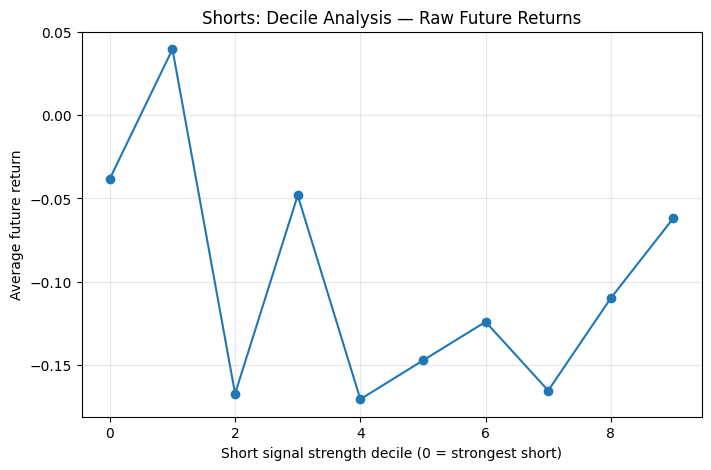

Short decile mean returns (raw):
signal_bin
0   -0.038115
1    0.039656
2   -0.167214
3   -0.048134
4   -0.170555
5   -0.147259
6   -0.124077
7   -0.165350
8   -0.109814
9   -0.061718
Name: fwd_ret, dtype: float64


In [132]:
df_short = short_df.copy()

df_short["signal_bin"] = pd.qcut(df_short["pred_30d"], q=10, labels=False)

bin_perf_short_raw = df_short.groupby("signal_bin")["fwd_ret"].mean()

plt.figure(figsize=(8, 5))
plt.plot(bin_perf_short_raw.index, bin_perf_short_raw.values, marker='o')
plt.xlabel("Short signal strength decile (0 = strongest short)")
plt.ylabel("Average future return")
plt.title("Shorts: Decile Analysis — Raw Future Returns")
plt.grid(alpha=0.3)
plt.show()

print("Short decile mean returns (raw):")
print(bin_perf_short_raw)
